## Predicting Operational Efficiency of Manufacturing Teams
### This dataset contains daily operational statistics for several production teams working in a garment manufacturing unit. Each record corresponds to one team on one specific day and captures metrics such as work time, idle time, team size, production targets, and achieved productivity.

### The goal is to predict team efficiency (or productivity ratio) using production-related and workforce-related features.

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

## Exploratory Data Analysis (EDA)


In [ ]:
df = pd.read_csv("/data/manufacturing_data.csv")
df.head()

,recordDate,fiscalQuarter,productionDept,dayOfWeek,team,plannedEfficiency,standardMinuteValue,workInProgress,overtimeMinutes,performanceBonus,idleMinutes,idleWorkers,styleChangeCount,workerCount,efficiencyScore
0,2/24/2015,Q4,Stitching Unit,Tuesday,Line-S1,0.6,22.53,708.0,5040,0,0.0,0,Minor Style Revision,42.0,0.268214
1,1/19/2015,Q3,Stitching Unit,Monday,Line-F3,0.8,11.41,1028.0,4380,50,0.0,0,No Style Change,31.0,0.800359
2,1/6/2015,Q1,Finishing & Quality,Tuesday,Line-C2,0.8,2.90,NaN,1440,0,0.0,0,No Style Change,8.0,0.681061
3,2/24/2015,Q4,Finishing & Quality,Tuesday,Line-S2,0.7,3.90,NaN,960,0,0.0,0,No Style Change,8.0,0.325000
4,1/4/2015,Q1,Finishing & Quality,Sunday,Line-C1,0.8,2.90,NaN,960,0,0.0,0,No Style Change,8.0,0.667604


Note : Here Fiscal Quarter means not yearly quarter but monthly quarter. eg. Q1->First Week

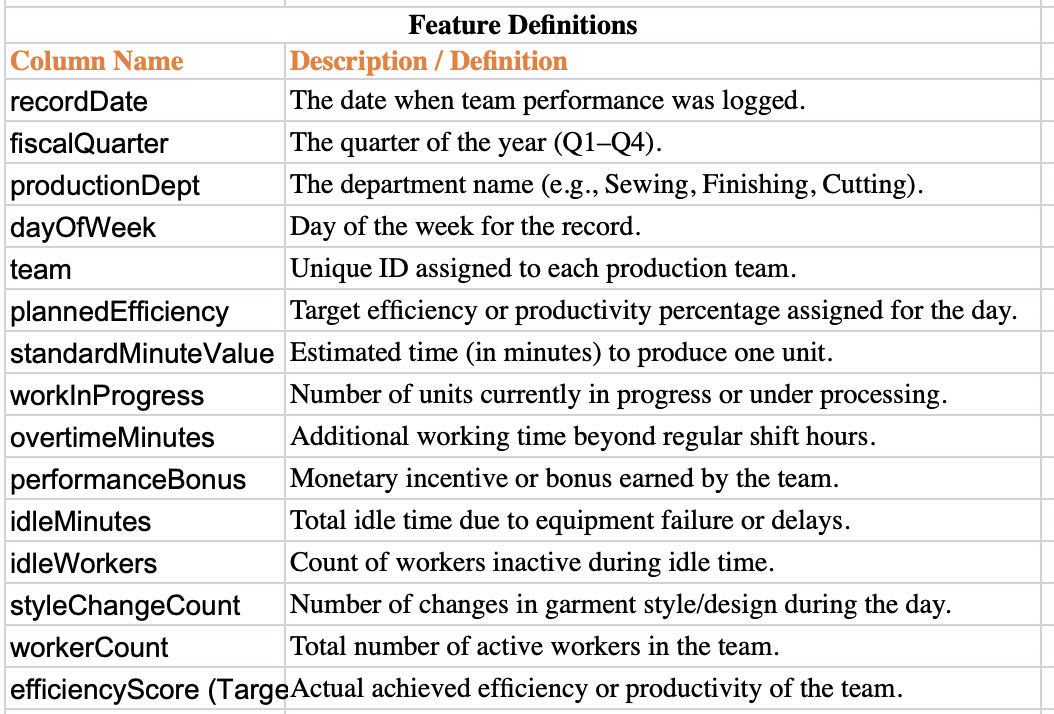

In [ ]:
# checking the shape of the dataset
df.shape

#the dataset has 1197 rows and 15 columns


(1197, 15)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   recordDate           1197 non-null   object 
 1   fiscalQuarter        1197 non-null   object 
 2   productionDept       1197 non-null   object 
 3   dayOfWeek            1197 non-null   object 
 4   team                 1197 non-null   object 
 5   plannedEfficiency    1197 non-null   float64
 6   standardMinuteValue  1197 non-null   float64
 7   workInProgress       691 non-null    float64
 8   overtimeMinutes      1197 non-null   int64  
 9   performanceBonus     1197 non-null   int64  
 10  idleMinutes          1197 non-null   float64
 11  idleWorkers          1197 non-null   int64  
 12  styleChangeCount     1197 non-null   object 
 13  workerCount          1197 non-null   float64
 14  efficiencyScore      1197 non-null   float64
dtypes: float64(6), int64(3), object(6)
mem

### workInProgress       691 non-null    -> Almost half has null value, so we can remove also it does not provide much info


In [ ]:
df["productionDept"].value_counts()

,count
productionDept,
Stitching Unit,691
Finishing & Quality,257
Finishing & Quality,249


### --> found "Finishing & Quality" 2 times

In [ ]:
df['productionDept'].unique()

array(['Stitching Unit', ' Finishing & Quality ', 'Finishing & Quality'],
      dtype=object)

### Found it has extra spaces

In [ ]:
df['fiscalQuarter'].value_counts()

,count
fiscalQuarter,
Q1,360
Q2,335
Q4,248
Q3,210
Q5,44


## Found that sometimes exceeding 28 days a month can cause Q5(Mar29)

making Q5 invaluable so we can move it to Q4

In [ ]:
df['dayOfWeek'].value_counts()

,count
dayOfWeek,
Wednesday,208
Sunday,203
Tuesday,201
Monday,199
Thursday,199
Saturday,187


### Maybe Friday is day off

(done for object types now lets see for numeric types below)

In [ ]:
df.describe()

,plannedEfficiency,standardMinuteValue,workInProgress,overtimeMinutes,performanceBonus,idleMinutes,idleWorkers,workerCount,efficiencyScore
count,1197.000000,1197.000000,691.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000
mean,0.729632,15.062172,1190.465991,4567.460317,38.210526,0.730159,0.369256,34.609858,0.735091
std,0.097891,10.943219,1837.455001,3348.823563,160.182643,12.709757,3.268987,22.197687,0.174488
min,0.070000,2.900000,7.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.233705
25%,0.700000,3.940000,774.500000,1440.000000,0.000000,0.000000,0.000000,9.000000,0.650307
50%,0.750000,15.260000,1039.000000,3960.000000,0.000000,0.000000,0.000000,34.000000,0.773333
75%,0.800000,24.260000,1252.500000,6960.000000,50.000000,0.000000,0.000000,57.000000,0.850253
max,0.800000,54.560000,23122.000000,25920.000000,3600.000000,300.000000,45.000000,89.000000,1.120437


## Found (overtime/work in progress) having mean 1197/691 and median 4567/1190 but max value is much larger 25920/23122...this could be outlier

## Found that efficiencyScore should be 0 to 1 but out max value is more than 1.12...that can cause problem

### (can use classification that will it be productive or not)

### (We can compare efficiencyScore i.e. actual productivity to plannedEfficiency i.e. our target productivity..

---

* If actual >= target, --> Productive
* If actual < target, --> Not Productive
---

In [ ]:
df[df["efficiencyScore"] > 1]

,recordDate,fiscalQuarter,productionDept,dayOfWeek,team,plannedEfficiency,standardMinuteValue,workInProgress,overtimeMinutes,performanceBonus,idleMinutes,idleWorkers,styleChangeCount,workerCount,efficiencyScore
16,2/12/2015,Q2,Stitching Unit,Thursday,Line-S2,0.80,22.52,1327.0,0,113,0.0,0,No Style Change,57.5,1.000345
20,2/11/2015,Q2,Stitching Unit,Wednesday,Line-S1,0.80,22.52,1498.0,0,113,0.0,0,No Style Change,57.0,1.000066
27,2/15/2015,Q3,Stitching Unit,Sunday,Line-S1,0.80,22.52,1420.0,6840,113,0.0,0,No Style Change,57.0,1.000230
36,2/11/2015,Q2,Finishing & Quality,Wednesday,Line-F1,0.70,4.15,NaN,1800,0,0.0,0,No Style Change,15.0,1.033156
88,2/2/2015,Q1,Stitching Unit,Monday,Line-S1,0.80,22.94,16882.0,7020,113,0.0,0,No Style Change,58.5,1.000602
102,1/31/2015,Q5,Stitching Unit,Saturday,Line-S2,0.80,22.52,1397.0,6840,113,0.0,0,No Style Change,57.0,1.000230
197,1/28/2015,Q4,Stitching Unit,Wednesday,Line-S3,0.80,22.52,1350.0,6840,113,0.0,0,No Style Change,57.0,1.000230
218,2/11/2015,Q2,Finishing & Quality,Wednesday,Line-P2,0.80,4.08,NaN,1080,0,0.0,0,No Style Change,9.0,1.020000
229,2/5/2015,Q1,Stitching Unit,Thursday,Line-S2,0.80,22.52,1300.0,6780,113,0.0,0,No Style Change,56.5,1.000446
243,2/12/2015,Q2,Finishing & Quality,Thursday,Line-F1,0.70,4.15,NaN,1800,0,0.0,0,No Style Change,15.0,1.096633


In [ ]:
df[df["workInProgress"].isnull()]

,recordDate,fiscalQuarter,productionDept,dayOfWeek,team,plannedEfficiency,standardMinuteValue,workInProgress,overtimeMinutes,performanceBonus,idleMinutes,idleWorkers,styleChangeCount,workerCount,efficiencyScore
2,1/6/2015,Q1,Finishing & Quality,Tuesday,Line-C2,0.8,2.90,NaN,1440,0,0.0,0,No Style Change,8.0,0.681061
3,2/24/2015,Q4,Finishing & Quality,Tuesday,Line-S2,0.7,3.90,NaN,960,0,0.0,0,No Style Change,8.0,0.325000
4,1/4/2015,Q1,Finishing & Quality,Sunday,Line-C1,0.8,2.90,NaN,960,0,0.0,0,No Style Change,8.0,0.667604
6,2/26/2015,Q4,Finishing & Quality,Thursday,Line-S1,0.5,3.94,NaN,3360,0,0.0,0,No Style Change,8.0,0.768847
7,2/28/2015,Q4,Finishing & Quality,Saturday,Line-S1,0.5,3.94,NaN,3360,0,0.0,0,No Style Change,8.0,0.768847
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1190,1/27/2015,Q4,Finishing & Quality,Tuesday,Line-C1,0.5,4.15,NaN,960,0,0.0,0,No Style Change,8.0,0.803542
1192,3/3/2015,Q1,Finishing & Quality,Tuesday,Line-F2,0.7,4.60,NaN,3360,0,0.0,0,No Style Change,8.0,0.354444
1193,3/7/2015,Q1,Finishing & Quality,Saturday,Line-F3,0.5,2.90,NaN,960,0,0.0,0,No Style Change,8.0,0.797500
1194,3/9/2015,Q2,Finishing & Quality,Monday,Line-F2,0.6,3.94,NaN,0,2880,0.0,0,No Style Change,12.0,0.864343


**Comparison between Actual Productivity and incentives over time**

/tmp/ipython-input-2253784378.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  line1 = sns.lineplot(x='recordDate', y='efficiencyScore', data=df_dt, ci= None, color='orange', label = 'actual productivity' )
/tmp/ipython-input-2253784378.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  line2 = sns.lineplot(x='recordDate', y='performanceBonus', data=df_dt, ci= None, color='darkgreen',ax=ax2, label = 'performanceBonus')


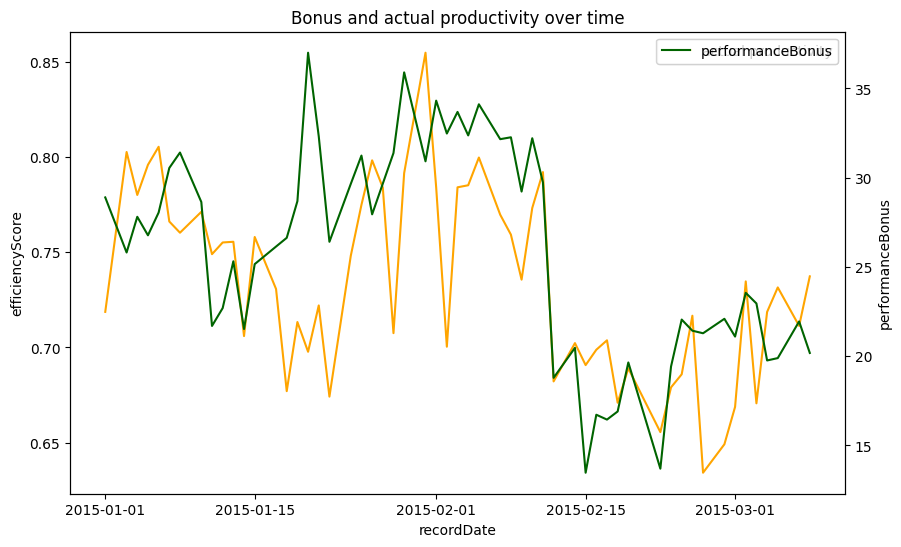

In [ ]:
# examining trend of efficiencyScore and performanceBonus
df['recordDate'] = pd.to_datetime(df['recordDate'])
df_dt = df[df.recordDate <= pd.to_datetime('2015-03-08')]
df_dt
plt.figure(figsize=(10,6))

line1 = sns.lineplot(x='recordDate', y='efficiencyScore', data=df_dt, ci= None, color='orange', label = 'actual productivity' )

ax2 = line1.twinx()
line2 = sns.lineplot(x='recordDate', y='performanceBonus', data=df_dt, ci= None, color='darkgreen',ax=ax2, label = 'performanceBonus')


plt.title("Bonus and actual productivity over time")
plt.show()

### "performanceBonus" and "actual productivity" show similar trends, with periods of low "performanceBonus" generally coinciding with periods of low "actual productivity", and peaks in productivity generally coinciding with peaks in "performanceBonus".

**Comparison between Actual and Targeted Productivity over time**

/tmp/ipython-input-474906215.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='recordDate', y='efficiencyScore', data=df, ci= None, color='orange', label='actual productivity' )
/tmp/ipython-input-474906215.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='recordDate', y='plannedEfficiency', data=df, ci= None, color='darkblue', label='targeted productivity')


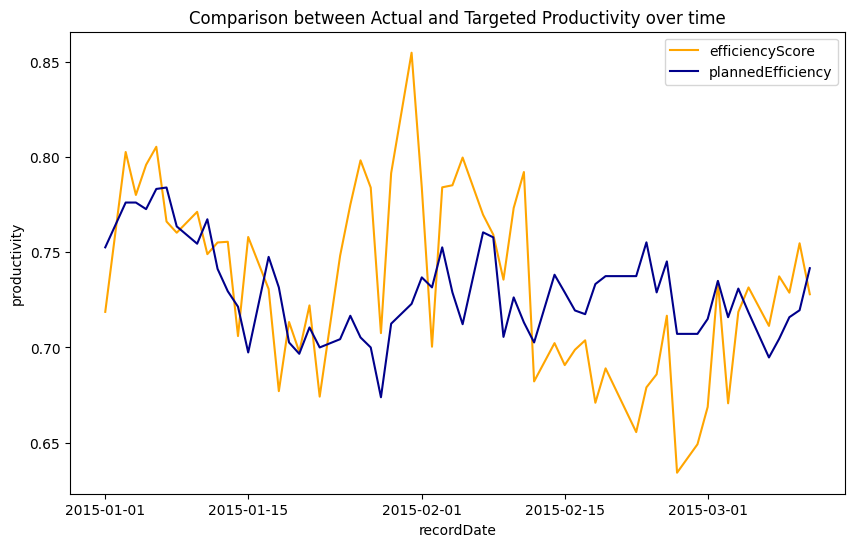

In [ ]:
# Line plot to check actual and targeted productivity
plt.figure(figsize=(10,6))

sns.lineplot(x='recordDate', y='efficiencyScore', data=df, ci= None, color='orange', label='actual productivity' )
sns.lineplot(x='recordDate', y='plannedEfficiency', data=df, ci= None, color='darkblue', label='targeted productivity')

plt.legend(labels=['efficiencyScore','plannedEfficiency'])
plt.ylabel("productivity")
plt.title("Comparison between Actual and Targeted Productivity over time")
plt.show()

### Actual productivity generally exceeded targeted productivity except from mid February to beginning of March where targets were not being met.

**Actual Productivity per Department over time**

/tmp/ipython-input-244476307.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='recordDate', y='efficiencyScore', hue='productionDept', style='productionDept',


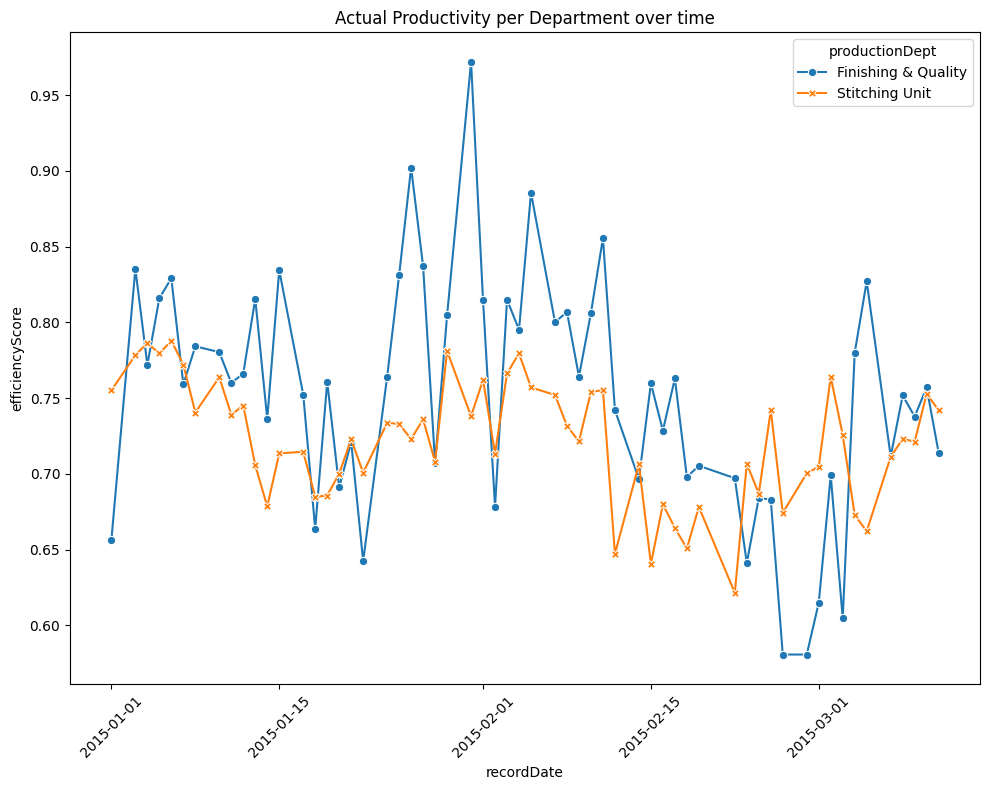

In [ ]:
# # Line plot to check actual productivity vs department
df['recordDate'] = pd.to_datetime(df['recordDate'])
df['productionDept'] = df['productionDept'].str.strip()
df_agg = df.groupby(['recordDate', 'productionDept'], as_index=False)['efficiencyScore'].mean()

plt.figure(figsize=(10,8))
sns.lineplot(x='recordDate', y='efficiencyScore', hue='productionDept', style='productionDept',
             data=df_agg, ci=None, markers=True, dashes=False, sort=False)
plt.title("Actual Productivity per Department over time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

###
The finishing department generally had higher actual productivity than the sewing department.

**Idle time by department**

/tmp/ipython-input-1484148148.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='productionDept', y='idleMinutes',hue ='team' ,data=df, ci= None)


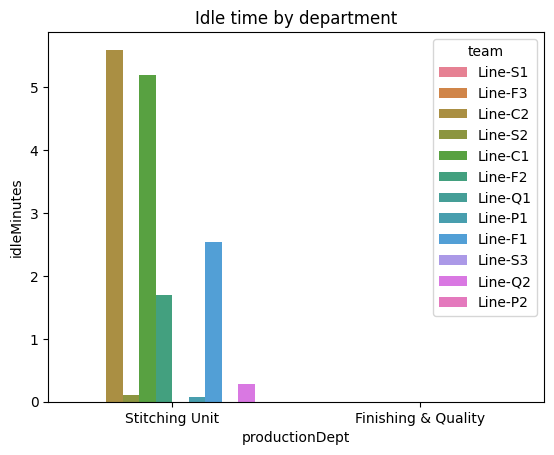

In [ ]:
sns.barplot(x='productionDept', y='idleMinutes',hue ='team' ,data=df, ci= None)
plt.title("Idle time by department")
plt.show()

### Only the stitching department had substantial idle time, with Line-F3's stitching team recording the highest idle time.

**Idle men by department**

/tmp/ipython-input-2570950802.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='productionDept', y='idleWorkers',hue ='team' ,data=df, ci= None, estimator=sum)


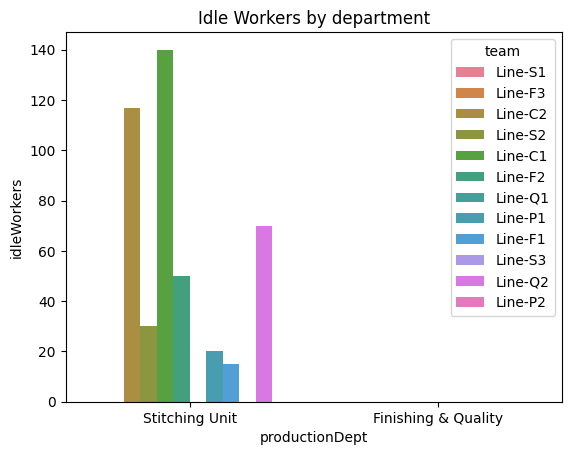

In [ ]:
sns.barplot(x='productionDept', y='idleWorkers',hue ='team' ,data=df, ci= None, estimator=sum)
plt.title("Idle Workers by department")
plt.show()

### Only the stitching department had idle workers, with Line-C1's stitching team recording the highest number of idle workers.

**Average Productivity of each team**

/tmp/ipython-input-1395340270.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.catplot(data=df,x='productionDept',y='efficiencyScore',hue='team', ci=None, kind = 'bar')


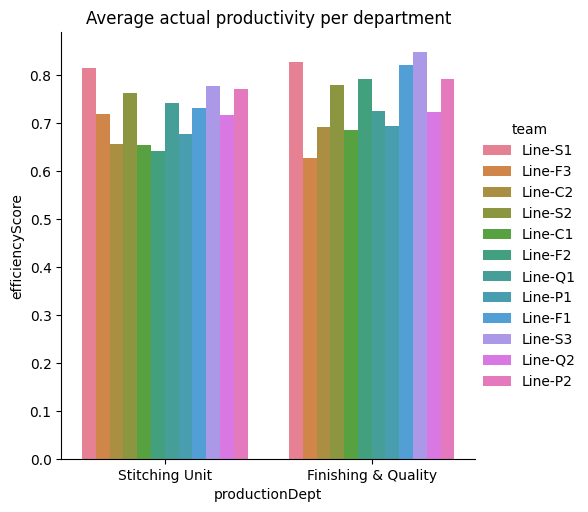

In [ ]:
sns.catplot(data=df,x='productionDept',y='efficiencyScore',hue='team', ci=None, kind = 'bar')
plt.title("Average actual productivity per department")
plt.show()

### Line-S1's stitching division had the highest average actual productivity in the stitching department, while in the finishing department Line-S3's finishing division had the highest.

### Line-F2's stitching division had the lowest average actual productivity in the stitching department, while in the finishing department Line-F3's finishing division had the lowest.

### Actual productivity, the target column, has the highest correlation (moderate positive correlation of 0.42) with targeted productivity.

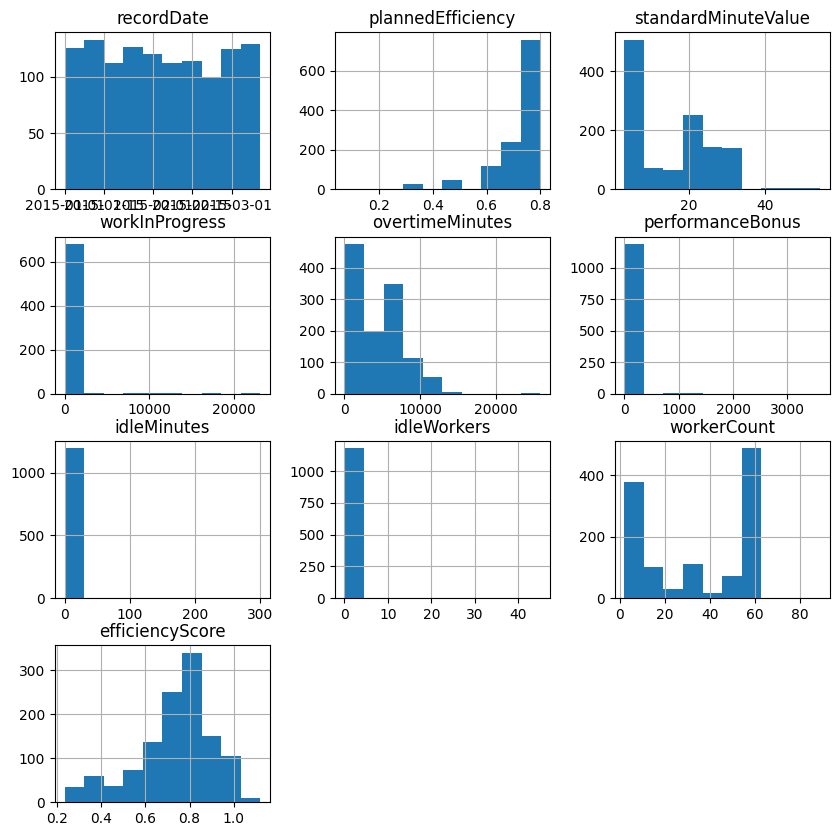

In [ ]:
#distribution of the dataset visualization
df.hist(figsize=(10,10))
plt.show()

In [ ]:
print(len(df[(df["idleMinutes"] > 0)]))
print(len(df[(df["idleWorkers"] > 0)]))
print(len(df[(df["performanceBonus"] > 0)])) #looking Skewed
print(len(df[(df["workInProgress"] > 0)]))

18
18
593
691


In [ ]:
df['idleWorkers'].unique()

array([ 0, 10, 45, 15, 37, 30, 35, 20, 25, 40])

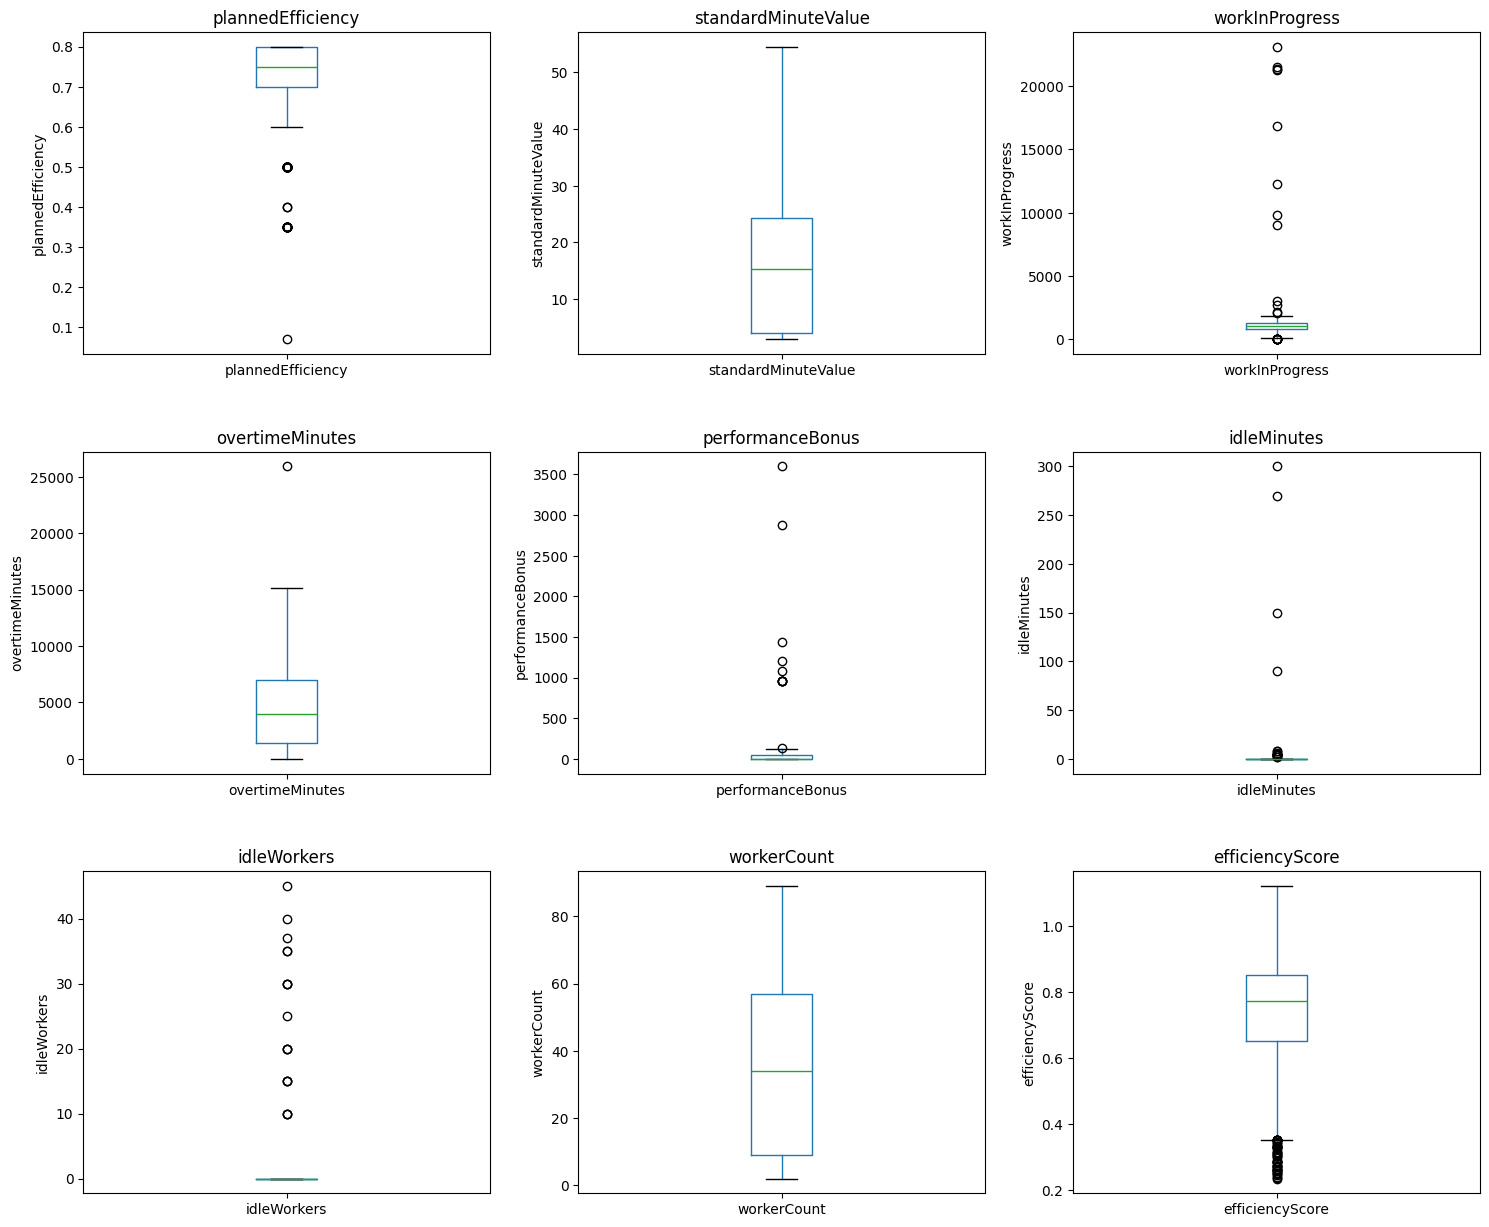

In [ ]:
# Checking for outliers in continuous data

fig,axes = plt.subplots(nrows=3, ncols=3,figsize=(15,8))

# Define the list of continuous columns
cols = ['plannedEfficiency', 'standardMinuteValue', 'workInProgress',
          'overtimeMinutes', 'performanceBonus', 'idleMinutes', 'idleWorkers',
          'workerCount', 'efficiencyScore']

#plotting boxplots
for i, ax in enumerate(axes.ravel()):
  df.boxplot(cols[i], grid=False, ax=ax)
  ax.set_title(f"{cols[i]}")
  ax.set_ylabel(cols[i])


fig.tight_layout()
plt.subplots_adjust(top=1.5)
plt.show()

In [ ]:

#checking for anomalies

#whether any columns has negative values
for col in cols:
  print(len(df[df[col] < 0]))
#none had values < 0

0
0
0
0
0
0
0
0
0


## Data Cleaning


In [ ]:
# Cleaning the extra space in productionDept column
df.loc[df["productionDept"] == " Finishing & Quality ", "productionDept"] = "Finishing & Quality"
df["productionDept"].value_counts()

,count
productionDept,
Stitching Unit,691
Finishing & Quality,506


In [ ]:
df["fiscalQuarter"].value_counts()

,count
fiscalQuarter,
Q1,360
Q2,335
Q4,248
Q3,210
Q5,44


In [ ]:
# Now merging Q5 with Q4 because it covers very few values of its own
df.loc[df["fiscalQuarter"] == "Q5", "fiscalQuarter"] = "Q4"
df["fiscalQuarter"].value_counts()

,count
fiscalQuarter,
Q1,360
Q2,335
Q4,292
Q3,210


In [ ]:
# Making Quarters numeric
df.loc[df["fiscalQuarter"] == "Q1", "fiscalQuarter"] = 1
df.loc[df["fiscalQuarter"] == "Q2", "fiscalQuarter"] = 2
df.loc[df["fiscalQuarter"] == "Q3", "fiscalQuarter"] = 3
df.loc[df["fiscalQuarter"] == "Q4", "fiscalQuarter"] = 4
df["fiscalQuarter"].value_counts()

,count
fiscalQuarter,
1,360
2,335
4,292
3,210


In [ ]:
df["fiscalQuarter"] = df["fiscalQuarter"].astype("int")
df[["fiscalQuarter"]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 1 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   fiscalQuarter  1197 non-null   int64
dtypes: int64(1)
memory usage: 9.5 KB


In [ ]:
#number of workers in each team should be a whole number
df['workerCount'].unique()

#there are some values with decimal points.

array([42. , 31. ,  8. , 59. , 56.5, 52. , 54. , 20. , 12. , 57.5, 55. ,
       58. , 57. , 33.5, 10. , 15. , 54.5, 50. , 56. , 34. , 18. ,  9. ,
       55.5, 33. , 58.5, 27. , 59.5, 38. , 22. , 25. ,  7. , 19. , 21. ,
       89. ,  5. , 14. , 51. , 31.5, 16. , 30.5, 60. , 46. , 53. , 32. ,
       35. , 45. , 28. , 49. ,  2. ,  4. , 26. , 29.5, 11. , 51.5, 24. ,
       17. , 47. , 44. ,  6. , 48. , 39. ])

In [ ]:
#**
#number of workers is currently a float, but can't have a fraction of worker...convert to int
df["workerCount"] = df["workerCount"].astype("int")
df.head(3)

,recordDate,fiscalQuarter,productionDept,dayOfWeek,team,plannedEfficiency,standardMinuteValue,workInProgress,overtimeMinutes,performanceBonus,idleMinutes,idleWorkers,styleChangeCount,workerCount,efficiencyScore
0,2015-02-24,4,Stitching Unit,Tuesday,Line-S1,0.6,22.53,708.0,5040,0,0.0,0,Minor Style Revision,42,0.268214
1,2015-01-19,3,Stitching Unit,Monday,Line-F3,0.8,11.41,1028.0,4380,50,0.0,0,No Style Change,31,0.800359
2,2015-01-06,1,Finishing & Quality,Tuesday,Line-C2,0.8,2.90,NaN,1440,0,0.0,0,No Style Change,8,0.681061


In [ ]:
#checking that the figures were truncated

df['workerCount'].unique()

array([42, 31,  8, 59, 56, 52, 54, 20, 12, 57, 55, 58, 33, 10, 15, 50, 34,
       18,  9, 27, 38, 22, 25,  7, 19, 21, 89,  5, 14, 51, 16, 30, 60, 46,
       53, 32, 35, 45, 28, 49,  2,  4, 26, 29, 11, 24, 17, 47, 44,  6, 48,
       39])

In [ ]:
# "efficiencyScore" should feature two decimals, just like "plannedEfficiency"
df["efficiencyScore"] = df["efficiencyScore"].round(2)
df.head(2)

,recordDate,fiscalQuarter,productionDept,dayOfWeek,team,plannedEfficiency,standardMinuteValue,workInProgress,overtimeMinutes,performanceBonus,idleMinutes,idleWorkers,styleChangeCount,workerCount,efficiencyScore
0,2015-02-24,4,Stitching Unit,Tuesday,Line-S1,0.6,22.53,708.0,5040,0,0.0,0,Minor Style Revision,42,0.27
1,2015-01-19,3,Stitching Unit,Monday,Line-F3,0.8,11.41,1028.0,4380,50,0.0,0,No Style Change,31,0.80


In [ ]:
df.isnull().sum()

,0
recordDate,0
fiscalQuarter,0
productionDept,0
dayOfWeek,0
team,0
plannedEfficiency,0
standardMinuteValue,0
workInProgress,506
overtimeMinutes,0
performanceBonus,0


### Removing date column as it has only short frame of dates (jan-march), which is probably not useful for our model and learning.

### Removing idleMinutes, idleWorkers as it contains only 18 non null values

### Removing workInProgress column has a significant number of missing values (only 691 out of 1197 are non-null). This means almost half of the data for this column is missing.

##While you could attempt to impute these missing values, with such a large proportion of missing data, imputation might not be reliable and could potentially introduce bias into your model.

In [ ]:
df.columns

Index(['recordDate', 'fiscalQuarter', 'productionDept', 'dayOfWeek', 'team',
       'plannedEfficiency', 'standardMinuteValue', 'workInProgress',
       'overtimeMinutes', 'performanceBonus', 'idleMinutes', 'idleWorkers',
       'styleChangeCount', 'workerCount', 'efficiencyScore'],
      dtype='object')

In [ ]:
print(df['styleChangeCount'].value_counts())

styleChangeCount
No Style Change         1050
Minor Style Revision     114
Major Design Shift        33
Name: count, dtype: int64


In [ ]:
print(len(df[(df["workInProgress"] > 0)]))

691


In [ ]:
df = df.drop(["recordDate", "idleMinutes", "idleWorkers", "workInProgress", "styleChangeCount"], axis=1)

In [ ]:
df.head(3)

,fiscalQuarter,productionDept,dayOfWeek,team,plannedEfficiency,standardMinuteValue,overtimeMinutes,performanceBonus,workerCount,efficiencyScore
0,4,Stitching Unit,Tuesday,Line-S1,0.6,22.53,5040,0,42,0.27
1,3,Stitching Unit,Monday,Line-F3,0.8,11.41,4380,50,31,0.80
2,1,Finishing & Quality,Tuesday,Line-C2,0.8,2.90,1440,0,8,0.68


In [ ]:
## Setting new column for classifieer based on whether targeted productivity was reached
df["productive"] = df["efficiencyScore"] >= df["plannedEfficiency"]
df.sample(10, random_state=12)

,fiscalQuarter,productionDept,dayOfWeek,team,plannedEfficiency,standardMinuteValue,overtimeMinutes,performanceBonus,workerCount,efficiencyScore,productive
778,4,Stitching Unit,Tuesday,Line-F3,0.80,30.40,3840,34,32,0.62,False
825,1,Finishing & Quality,Saturday,Line-F1,0.80,4.30,960,0,8,0.45,False
250,1,Finishing & Quality,Sunday,Line-C2,0.65,4.15,960,0,8,1.01,True
945,4,Stitching Unit,Sunday,Line-Q1,0.70,18.79,3240,30,57,0.63,False
221,4,Finishing & Quality,Wednesday,Line-F2,0.80,4.60,1080,0,9,0.90,True
773,3,Stitching Unit,Sunday,Line-S3,0.60,30.10,6960,30,58,0.48,False
300,2,Stitching Unit,Wednesday,Line-Q2,0.75,21.82,6000,34,50,0.75,True
971,2,Stitching Unit,Monday,Line-F1,0.75,26.82,7020,65,58,0.85,True
171,3,Stitching Unit,Thursday,Line-F2,0.80,30.10,600,63,59,0.80,True
557,4,Finishing & Quality,Saturday,Line-Q1,0.75,3.94,240,0,2,0.97,True


## Machine Learning Prepration

In [ ]:
df["productionDept"].unique()

array(['Stitching Unit', 'Finishing & Quality'], dtype=object)

### As we have only 2 values for productionDept we can make it bool..it will ask is dept is sewing giving ans true or false

In [ ]:
# Convert department columb to boolean
df = df.rename(columns={"productionDept": "dept_stitching"})
df["dept_stitching"] = df["dept_stitching"].map({"Finishing & Quality": 0, "Stitching Unit": 1}).astype("int64")
df.head(10)

,fiscalQuarter,dept_stitching,dayOfWeek,team,plannedEfficiency,standardMinuteValue,overtimeMinutes,performanceBonus,workerCount,efficiencyScore,productive
0,4,1,Tuesday,Line-S1,0.60,22.53,5040,0,42,0.27,False
1,3,1,Monday,Line-F3,0.80,11.41,4380,50,31,0.80,True
2,1,0,Tuesday,Line-C2,0.80,2.90,1440,0,8,0.68,False
3,4,0,Tuesday,Line-S2,0.70,3.90,960,0,8,0.32,False
4,1,0,Sunday,Line-C1,0.80,2.90,960,0,8,0.67,False
5,3,1,Monday,Line-F2,0.80,30.10,0,0,59,0.80,True
6,4,0,Thursday,Line-S1,0.50,3.94,3360,0,8,0.77,True
7,4,0,Saturday,Line-S1,0.50,3.94,3360,0,8,0.77,True
8,4,1,Saturday,Line-C1,0.65,22.52,10170,26,56,0.65,True
9,1,1,Thursday,Line-Q1,0.75,18.79,6240,45,52,0.75,True


## Now "fiscalQuarter" having value 1 and 4 can conflict with biasness

In [ ]:
# Making quarter column into dummies (numeric order is not actually part of these values so they should be categorical)
df = pd.concat([df, pd.get_dummies(df["fiscalQuarter"], prefix="Q")], axis=1).drop(["fiscalQuarter"],axis=1)
df.sample(10, random_state=14)

,dept_stitching,dayOfWeek,team,plannedEfficiency,standardMinuteValue,overtimeMinutes,performanceBonus,workerCount,efficiencyScore,productive,Q_1,Q_2,Q_3,Q_4
959,0,Sunday,Line-S3,0.75,3.94,1620,0,9,0.96,True,False,False,False,True
464,1,Wednesday,Line-S3,0.80,29.40,6840,63,57,0.80,True,True,False,False,False
672,0,Tuesday,Line-F1,0.70,3.94,3360,0,8,0.56,False,True,False,False,False
321,1,Sunday,Line-F3,0.65,18.79,3960,26,33,0.65,True,True,False,False,False
282,1,Thursday,Line-P2,0.80,11.41,3660,50,30,0.80,True,True,False,False,False
307,0,Monday,Line-S2,0.80,3.94,960,0,8,0.80,True,True,False,False,False
609,0,Wednesday,Line-C1,0.60,3.94,960,0,8,0.41,False,False,False,False,True
1123,1,Monday,Line-P2,0.80,15.26,3720,38,34,0.80,True,False,False,True,False
877,0,Sunday,Line-F3,0.80,2.90,1800,0,10,0.80,True,False,False,True,False
950,1,Saturday,Line-Q1,0.75,18.79,6240,45,52,0.75,True,False,False,False,True


In [ ]:
# Day column to dummies
df = pd.concat([df, pd.get_dummies(df["dayOfWeek"], prefix="day")], axis=1).drop(["dayOfWeek"],axis=1)
df.sample(10, random_state=14)

,dept_stitching,team,plannedEfficiency,standardMinuteValue,overtimeMinutes,performanceBonus,workerCount,efficiencyScore,productive,Q_1,Q_2,Q_3,Q_4,day_Monday,day_Saturday,day_Sunday,day_Thursday,day_Tuesday,day_Wednesday
959,0,Line-S3,0.75,3.94,1620,0,9,0.96,True,False,False,False,True,False,False,True,False,False,False
464,1,Line-S3,0.80,29.40,6840,63,57,0.80,True,True,False,False,False,False,False,False,False,False,True
672,0,Line-F1,0.70,3.94,3360,0,8,0.56,False,True,False,False,False,False,False,False,False,True,False
321,1,Line-F3,0.65,18.79,3960,26,33,0.65,True,True,False,False,False,False,False,True,False,False,False
282,1,Line-P2,0.80,11.41,3660,50,30,0.80,True,True,False,False,False,False,False,False,True,False,False
307,0,Line-S2,0.80,3.94,960,0,8,0.80,True,True,False,False,False,True,False,False,False,False,False
609,0,Line-C1,0.60,3.94,960,0,8,0.41,False,False,False,False,True,False,False,False,False,False,True
1123,1,Line-P2,0.80,15.26,3720,38,34,0.80,True,False,False,True,False,True,False,False,False,False,False
877,0,Line-F3,0.80,2.90,1800,0,10,0.80,True,False,False,True,False,False,False,True,False,False,False
950,1,Line-Q1,0.75,18.79,6240,45,52,0.75,True,False,False,False,True,False,True,False,False,False,False


In [ ]:
print(df["team"].value_counts())
print(df["team"].unique())

team
Line-S2    109
Line-C2    109
Line-S1    105
Line-F1    105
Line-Q1    104
Line-Q2    100
Line-P2     99
Line-C1     96
Line-S3     95
Line-F3     94
Line-F2     93
Line-P1     88
Name: count, dtype: int64
['Line-S1' 'Line-F3' 'Line-C2' 'Line-S2' 'Line-C1' 'Line-F2' 'Line-Q1'
 'Line-P1' 'Line-F1' 'Line-S3' 'Line-Q2' 'Line-P2']


In [ ]:
# Team column to dummies
df = pd.concat([df, pd.get_dummies(df["team"], prefix="team")], axis=1).drop(["team"],axis=1)
df.sample(10, random_state=14)

,dept_stitching,plannedEfficiency,standardMinuteValue,overtimeMinutes,performanceBonus,workerCount,efficiencyScore,productive,Q_1,Q_2,...,team_Line-F1,team_Line-F2,team_Line-F3,team_Line-P1,team_Line-P2,team_Line-Q1,team_Line-Q2,team_Line-S1,team_Line-S2,team_Line-S3
959,0,0.75,3.94,1620,0,9,0.96,True,False,False,...,False,False,False,False,False,False,False,False,False,True
464,1,0.80,29.40,6840,63,57,0.80,True,True,False,...,False,False,False,False,False,False,False,False,False,True
672,0,0.70,3.94,3360,0,8,0.56,False,True,False,...,True,False,False,False,False,False,False,False,False,False
321,1,0.65,18.79,3960,26,33,0.65,True,True,False,...,False,False,True,False,False,False,False,False,False,False
282,1,0.80,11.41,3660,50,30,0.80,True,True,False,...,False,False,False,False,True,False,False,False,False,False
307,0,0.80,3.94,960,0,8,0.80,True,True,False,...,False,False,False,False,False,False,False,False,True,False
609,0,0.60,3.94,960,0,8,0.41,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1123,1,0.80,15.26,3720,38,34,0.80,True,False,False,...,False,False,False,False,True,False,False,False,False,False
877,0,0.80,2.90,1800,0,10,0.80,True,False,False,...,False,False,True,False,False,False,False,False,False,False
950,1,0.75,18.79,6240,45,52,0.75,True,False,False,...,False,False,False,False,False,True,False,False,False,False


In [ ]:
# Saving cleaned data
df.to_csv("cleaned_productivity.csv",index=False)

## Building Models


### Building the tree

In [ ]:
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

In [ ]:
#* Feature and target columns

In [ ]:
X = df.drop(["efficiencyScore", "productive"], axis=1)
y = df["productive"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=24)

In [ ]:
tree = DecisionTreeClassifier(max_depth=3, random_state=24)
tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=24)

In [ ]:
y_pred = tree.predict(X_test)

## Visualizing and Evaluating the Tree

In [ ]:
from sklearn.metrics import accuracy_score
print("Accuracy: ", round(accuracy_score(y_test, y_pred), 2))

Accuracy:  0.82


In [ ]:
tree.classes_

array([False,  True])

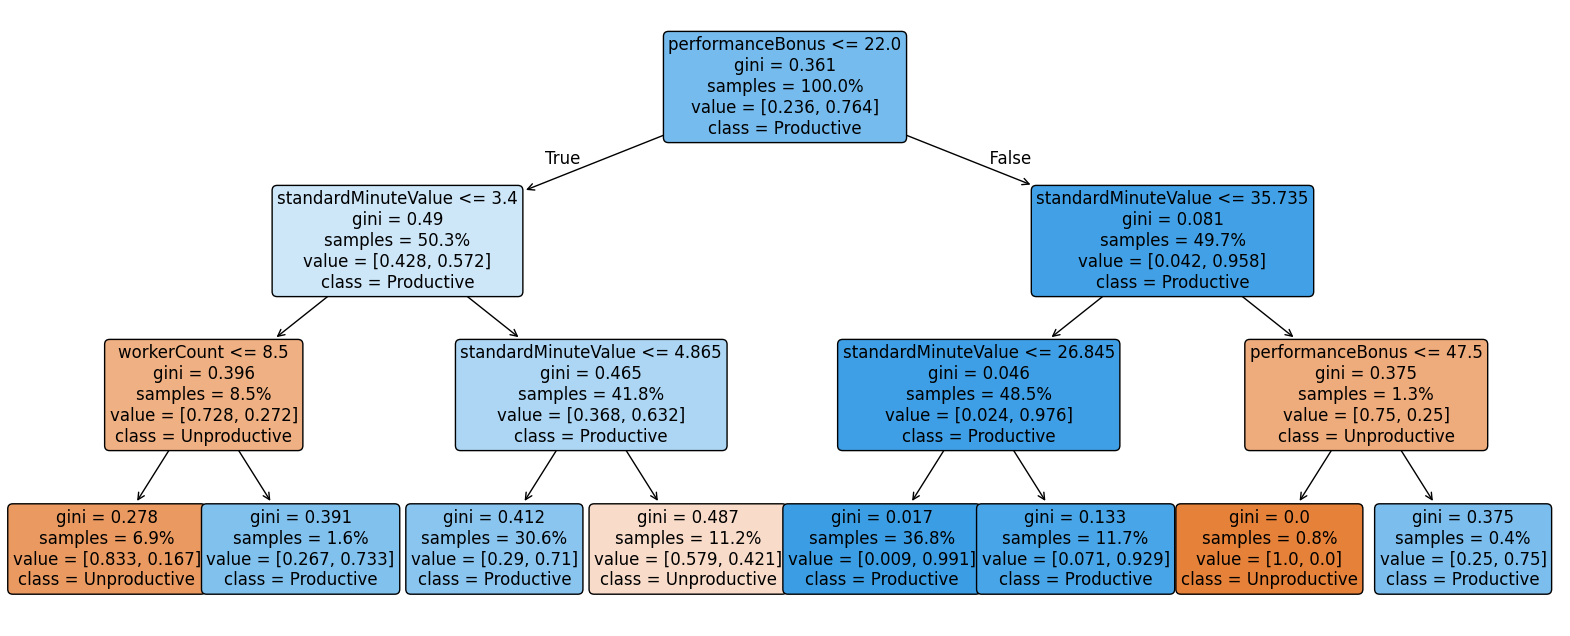

In [ ]:
plt.figure(figsize =[20.0,8.0])

# Plotting the tree with some specific parameters

_ = plot_tree(tree,
              feature_names=X.columns,
              class_names=["Unproductive", "Productive"],
              filled=True,
              rounded=True,
              proportion=True,
              fontsize=12
              )

#### Less gini means less blending means better for classification

## So after all that data preprocessing...Only performanceBonus, standardMinuteValue and workerCount matters to find productive day or not

Feature Importances:
Variable: performanceBonus, Importance: 0.59
Variable: standardMinuteValue, Importance: 0.35
Variable: workerCount, Importance: 0.06
Variable: dept_stitching, Importance: 0.0
Variable: plannedEfficiency, Importance: 0.0
Variable: overtimeMinutes, Importance: 0.0
Variable: Q_1, Importance: 0.0
Variable: Q_2, Importance: 0.0
Variable: Q_3, Importance: 0.0
Variable: Q_4, Importance: 0.0
Variable: day_Monday, Importance: 0.0
Variable: day_Saturday, Importance: 0.0
Variable: day_Sunday, Importance: 0.0
Variable: day_Thursday, Importance: 0.0
Variable: day_Tuesday, Importance: 0.0
Variable: day_Wednesday, Importance: 0.0
Variable: team_Line-C1, Importance: 0.0
Variable: team_Line-C2, Importance: 0.0
Variable: team_Line-F1, Importance: 0.0
Variable: team_Line-F2, Importance: 0.0
Variable: team_Line-F3, Importance: 0.0
Variable: team_Line-P1, Importance: 0.0
Variable: team_Line-P2, Importance: 0.0
Variable: team_Line-Q1, Importance: 0.0
Variable: team_Line-Q2, Importance: 

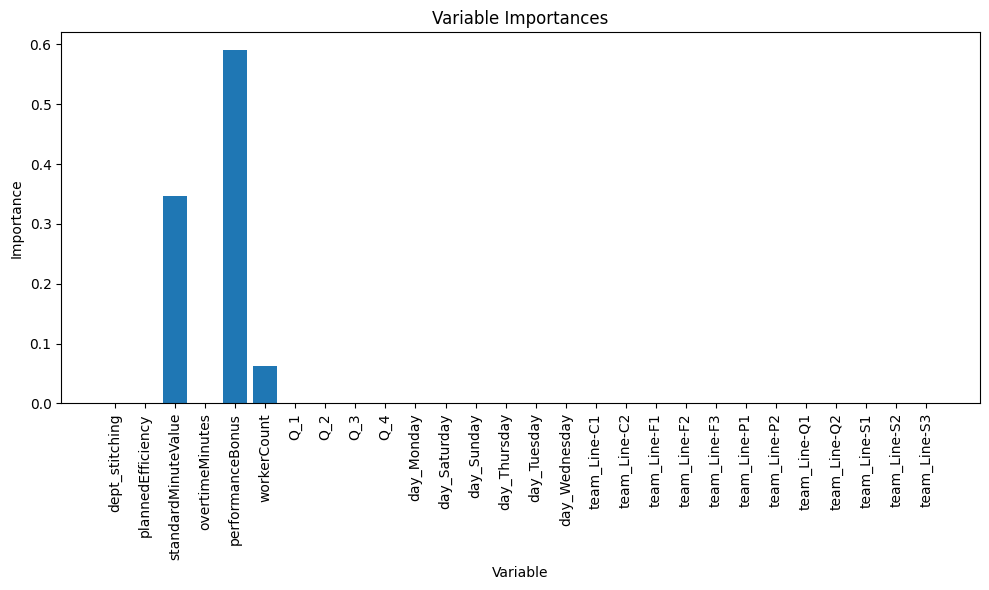

In [ ]:
# List of tuples with variable and importance using the Decision Tree model
importances = tree.feature_importances_
x_cols = X_train.columns # Get feature names from the training data
feature_importances = [(feature, round(importance, 2)) for feature, importance in zip(x_cols, importances)]

#sorting the values in descending order
feature_importances = sorted(feature_importances, key = lambda x: x[1], reverse = True)

# Printing out the feature and importances
print("Feature Importances:")
for feat, signif in feature_importances:
  print(f'Variable: {feat}, Importance: {signif}')

# Making a bar chart
plt.figure(figsize=(10, 6)) # Add figure size for better readability
plt.bar(x_cols, importances)
# Tick labels for x axis
plt.xticks(rotation='vertical')

plt.ylabel('Importance'); plt.xlabel('Variable'); plt.title('Variable Importances');
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = tree.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print("___"*20)


[[ 39  37]
 [  7 157]]
____________________________________________________________




```
              Predicted
              False         True
Actual False   39(TN)      37(FP)
Actual True     7(FN)     157(TP)

```
* 39(TN) -> How many unproductives were actually unproductive
* 37(FP) -> What does it say is productive but actually is unproductive
* 157(TP) -> How many productives were actually productive
* 7(FN) -> What does it says unproductive bu acutally was productive

False Negative and False Positive says our model isn't perfect

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision: ", round(precision_score(y_test, y_pred), 2))
print("Recall: ", round(recall_score(y_test, y_pred), 2))
print("F1 Score: ", round(f1_score(y_test, y_pred), 2))
print("___"*20)
print("Accuracy:", round(tree.score(X_test, y_test), 2))

Precision:  0.81
Recall:  0.96
F1 Score:  0.88
____________________________________________________________
Accuracy: 0.82


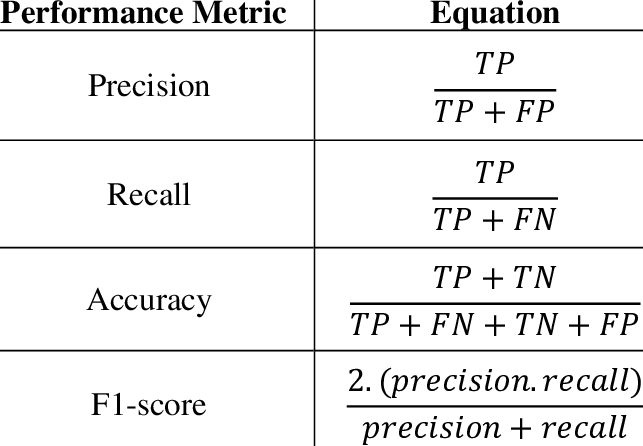

In [ ]:
# From cross validation
from sklearn.model_selection import cross_val_score
scores = cross_val_score(tree, X, y, cv=10) #10 folds

print("Cross Validation Accuracy Scores:", scores.round(2))
print("Mean Cross Validation Score:", scores.mean().round(2))

Cross Validation Accuracy Scores: [0.84 0.84 0.81 0.85 0.8  0.82 0.82 0.85 0.82 0.84]
Mean Cross Validation Score: 0.83


In [ ]:
from sklearn.model_selection import cross_validate

multiple_cross_scores = cross_validate(
    tree,
    X, y, cv=10,
    scoring= ("precision", "recall", "f1"))
print("Mean Cross Validated Precision:", round(multiple_cross_scores["test_precision"]. mean(), 2))
print("Mean Cross Validated recall:", round(multiple_cross_scores["test_recall"]. mean(), 2))
print("Mean Cross Validated F1:", round(multiple_cross_scores["test_f1"]. mean(), 2))

Mean Cross Validated Precision: 0.86
Mean Cross Validated recall: 0.92
Mean Cross Validated F1: 0.89


## Tells that our model is not overfitted
___

## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(
                    oob_score=True,
                    random_state=24,
                     )
forest.fit(X_train, y_train)

y_pred_forest = forest.predict(X_test)

print("Accuracy on Random Forest :", round(accuracy_score(y_test,y_pred_forest), 2))

Accuracy on Random Forest : 0.81


Feature Importances:
Variable: standardMinuteValue, Importance: 0.16
Variable: performanceBonus, Importance: 0.14
Variable: overtimeMinutes, Importance: 0.12
Variable: workerCount, Importance: 0.12
Variable: plannedEfficiency, Importance: 0.08
Variable: dept_stitching, Importance: 0.03
Variable: Q_1, Importance: 0.02
Variable: Q_2, Importance: 0.02
Variable: Q_3, Importance: 0.02
Variable: Q_4, Importance: 0.02
Variable: day_Monday, Importance: 0.02
Variable: day_Saturday, Importance: 0.02
Variable: day_Sunday, Importance: 0.02
Variable: day_Thursday, Importance: 0.02
Variable: day_Tuesday, Importance: 0.02
Variable: day_Wednesday, Importance: 0.02
Variable: team_Line-C2, Importance: 0.02
Variable: team_Line-F2, Importance: 0.02
Variable: team_Line-C1, Importance: 0.01
Variable: team_Line-F1, Importance: 0.01
Variable: team_Line-F3, Importance: 0.01
Variable: team_Line-P1, Importance: 0.01
Variable: team_Line-P2, Importance: 0.01
Variable: team_Line-Q1, Importance: 0.01
Variable: team_

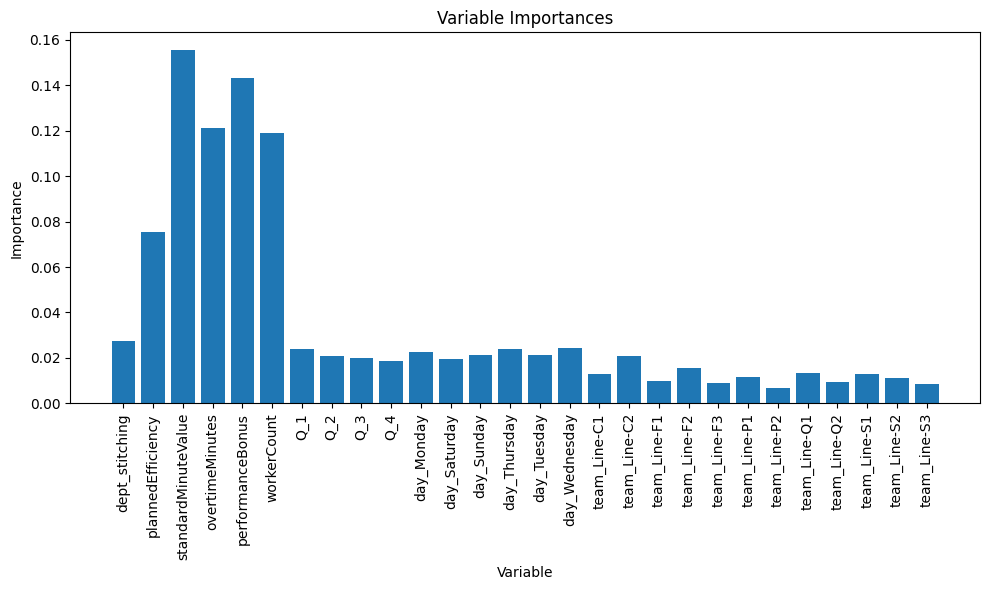

In [ ]:
# List of tuples with variable and importance using the forest model
importances = forest.feature_importances_
x_cols = X_train.columns # Get feature names from the training data
feature_importances = [(feature, round(importance, 2)) for feature, importance in zip(x_cols, importances)]

#sorting the values in descending order
feature_importances = sorted(feature_importances, key = lambda x: x[1], reverse = True)

# Printing out the feature and importances
print("Feature Importances:")
for feat, signif in feature_importances:
  print(f'Variable: {feat}, Importance: {signif}')

# Making a bar chart
plt.figure(figsize=(10, 6)) # Add figure size for better readability
plt.bar(x_cols, importances)
# Tick labels for x axis
plt.xticks(rotation='vertical')

plt.ylabel('Importance'); plt.xlabel('Variable'); plt.title('Variable Importances');
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()